In [1]:
# Import data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [3]:
df.shape, df.columns

((1000, 8),
 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
        'test preparation course', 'math score', 'reading score',
        'writing score'],
       dtype='object'))

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
df.describe(include='O')

,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


In [8]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['total'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total'] / 3

In [11]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [12]:
df.rename(columns={'race/ethnicity': 'race'}, inplace=True)

In [13]:
# Count unique values
df.nunique()

gender                           2
race                             5
parental level of education      6
lunch                            2
test preparation course          2
math score                      81
reading score                   72
writing score                   77
total                          194
average                        194
dtype: int64

In [14]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['gender', 'race', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')

In [15]:
for col in categorical_columns:
    print(f"{col} -> {df[col].unique()}")

gender -> ['female' 'male']
race -> ['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education -> ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch -> ['standard' 'free/reduced']
test preparation course -> ['none' 'completed']


In [16]:
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

gender: 2 unique values
race: 5 unique values
parental level of education: 6 unique values
lunch: 2 unique values
test preparation course: 2 unique values


In [17]:
numerical_columns = df.select_dtypes(include=[np.number]).columns
numerical_columns

Index(['math score', 'reading score', 'writing score', 'total', 'average'], dtype='object')

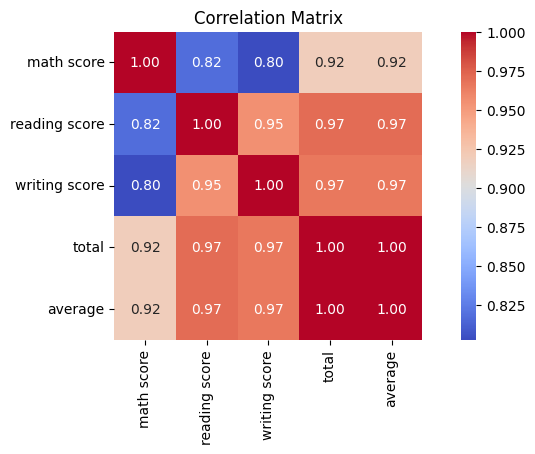

In [18]:
# Corr matrix
corr_matrix = df[numerical_columns].corr()
plt.figure(figsize=(10, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

### Visualise Histohrams and KDE

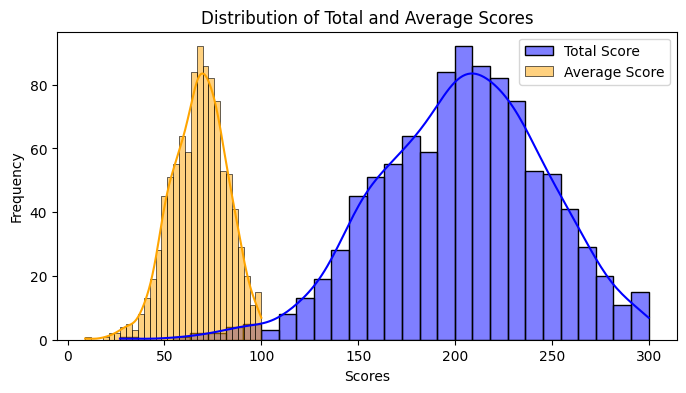

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(df['total'], bins=30, kde=True, color='blue', label='Total Score')
sns.histplot(df['average'], bins=30, kde=True, color='orange', label='Average Score')
plt.title('Distribution of Total and Average Scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.legend()
plt.show()

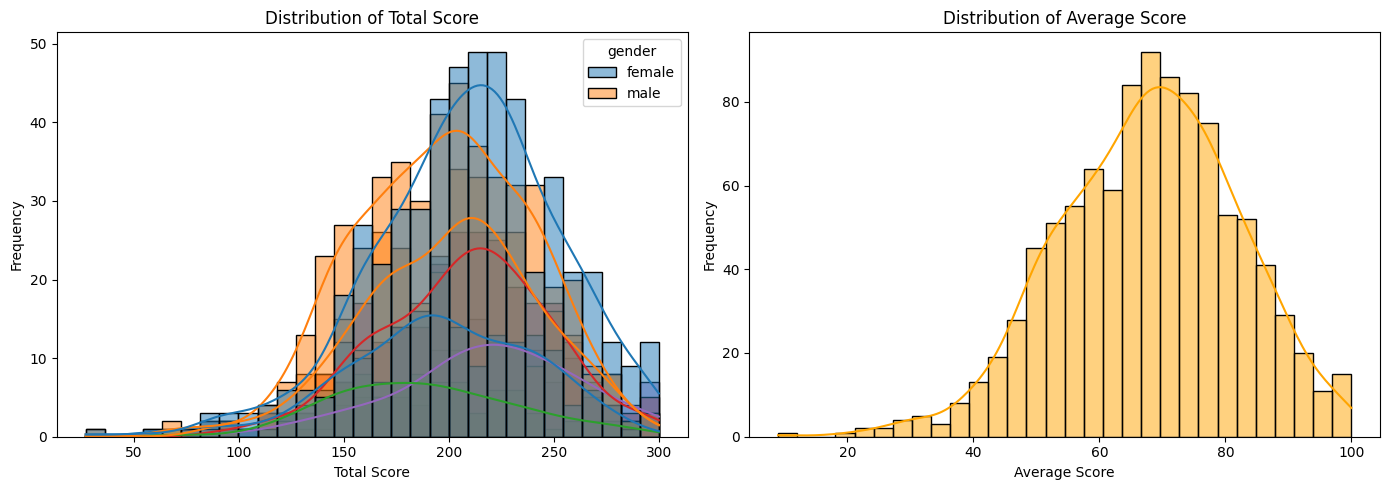

In [24]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

sns.histplot(data=df,x= df['total'], bins=30, kde=True, color='blue', hue='race')
sns.histplot(data=df,x= df['total'], bins=30, kde=True, color='blue', hue='gender')
plt.title('Distribution of Total Score')
plt.xlabel('Total Score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['average'], bins=30, kde=True, color='orange')
plt.title('Distribution of Average Score')
plt.xlabel('Average Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


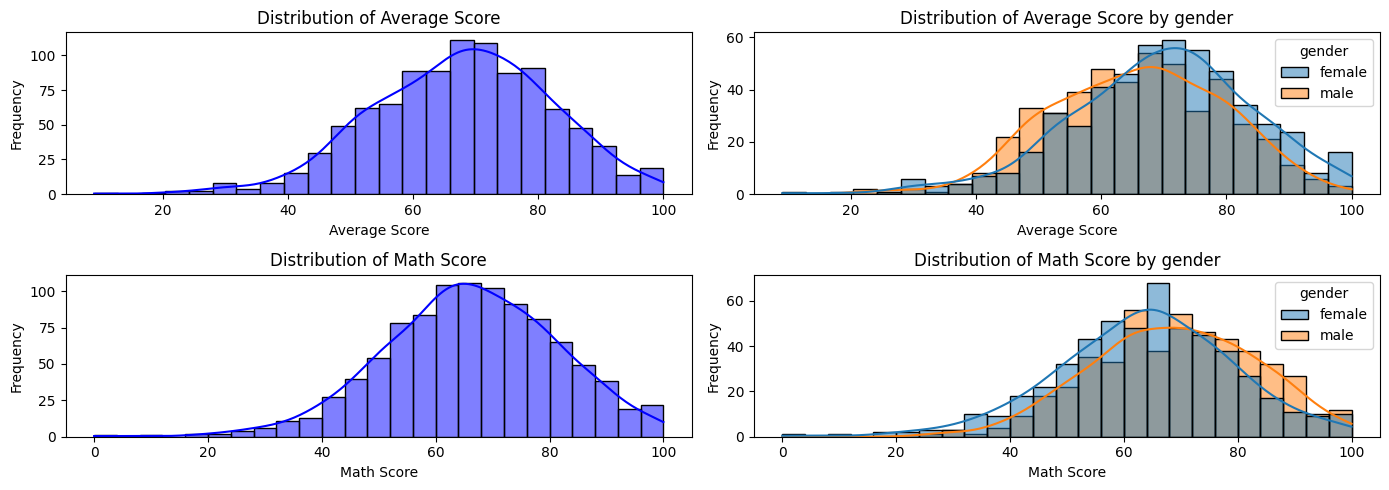

In [36]:
# Dstribution of Average score and Maths score with gender

plt.figure(figsize=(14, 5))

plt.subplot(2, 2, 1)
sns.histplot(data=df,x= df['average'], kde=True, color='blue')
plt.title('Distribution of Average Score')
plt.xlabel('Average Score')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.histplot(data=df,x= df['average'],kde=True, color='blue', hue='gender')
plt.title('Distribution of Average Score by gender')
plt.xlabel('Average Score')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
sns.histplot(data=df,x= df['math score'], kde=True, color='blue')
plt.title('Distribution of Math Score')
plt.xlabel('Math Score')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.histplot(data=df,x= df['math score'],kde=True, color='blue', hue='gender')
plt.title('Distribution of Math Score by gender')
plt.xlabel('Math Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


From above graph we can conclude, Female perform better than males

In [33]:
df.head(1)

,gender,race,parental level of education,lunch,test preparation course,math score,reading score,writing score,total,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667


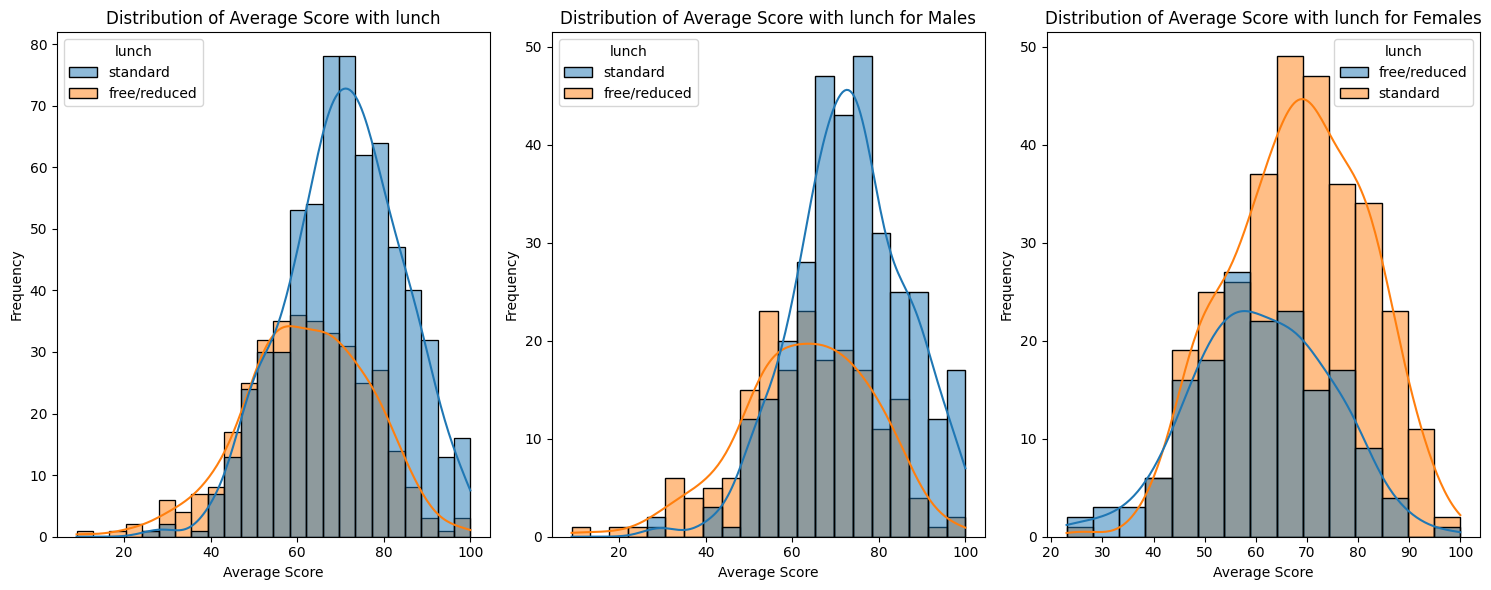

In [62]:
# Distribution of average with lunch
plt.figure(figsize=(15,6))

# plt.subplot(2, 2, 1)
# sns.histplot(data=df,x= df['average'], kde=True, color='blue')
# plt.title('Distribution of Average Score')
# plt.xlabel('Average Score')
# plt.ylabel('Frequency')

plt.subplot(131)
sns.histplot(data=df,x= df['average'],hue='lunch', kde=True, color='blue')
plt.title('Distribution of Average Score with lunch')
plt.xlabel('Average Score')
plt.ylabel('Frequency')

plt.subplot(132)
sns.histplot(data=df[df['gender']=='female'],x= df['average'],hue='lunch', kde=True, color='blue')
plt.title('Distribution of Average Score with lunch for Males')
plt.xlabel('Average Score')
plt.ylabel('Frequency')

plt.subplot(133)
sns.histplot(data=df[df['gender']=='male'],x= df['average'],hue='lunch', kde=True, color='blue')
plt.title('Distribution of Average Score with lunch for Females')
plt.xlabel('Average Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

From above graph we can conclude, Standard lunch helps perform better irrespective of gender

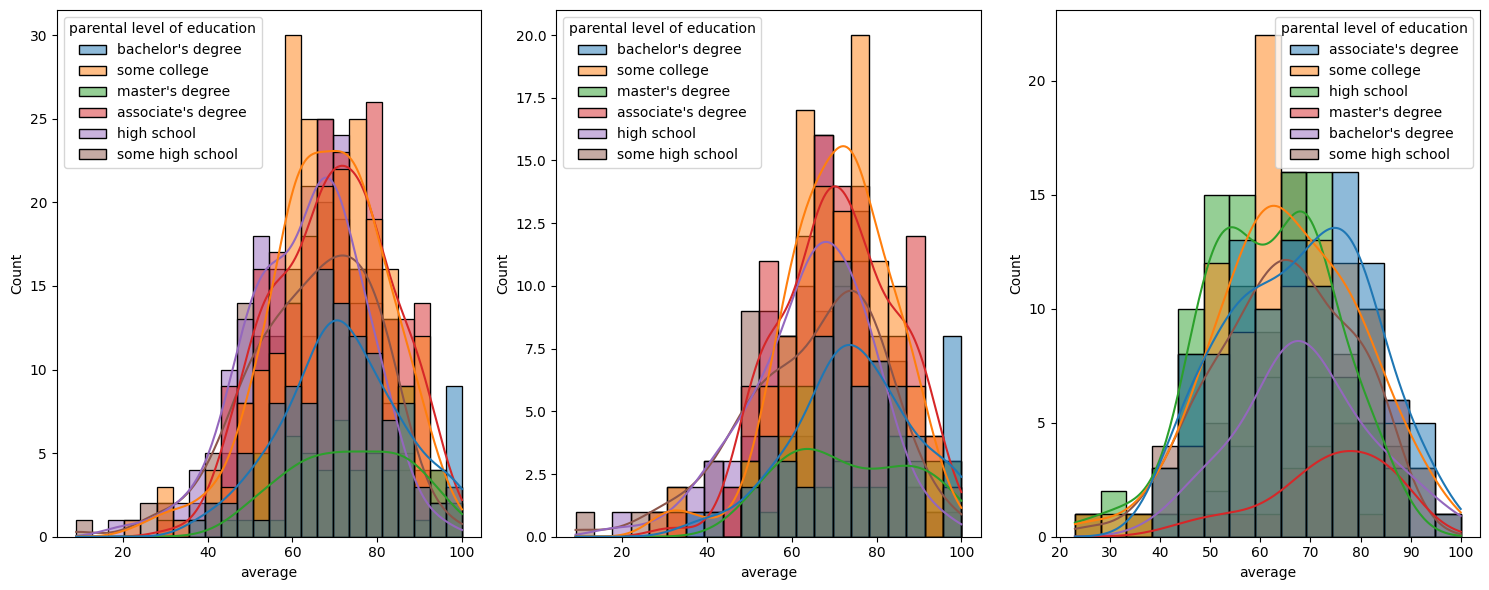

In [58]:
# Distribution of average with Parental level of education

plt.figure(figsize=(15,6))

plt.subplot(1,3,1)
sns.histplot(data=df,x= df['average'],hue='parental level of education', kde=True)

plt.subplot(1,3,2)
sns.histplot(data=df[df['gender']=='female'],x= df['average'],hue='parental level of education', kde=True)

plt.subplot(1,3,3)
sns.histplot(data=df[df['gender']=='male'],x= df['average'],hue='parental level of education', kde=True)

plt.tight_layout()


Conclusion from the above 3 graphs:
1. Irrespective of parents education level, the average score of students is almost same. So we can say that parents education level does not have much effect on students performance.
2. No effect of parents education level on students performance is observed in case of females
3. In case of males Masters and associate degree parents, students perform better.

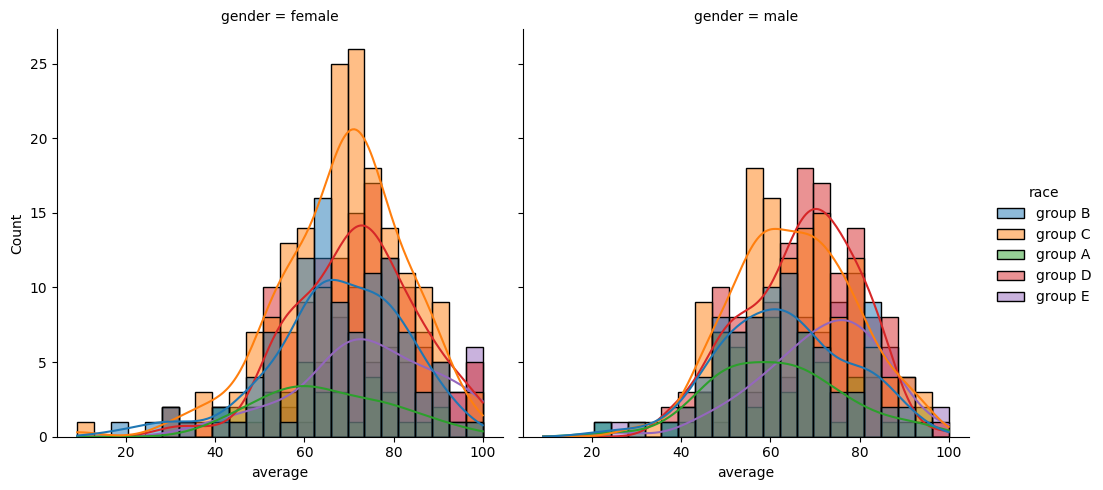

In [78]:
# Students performance with race

sns.displot(
    data=df,
    x='average',
    kde=True,
    hue='race',
    col='gender'
)

plt.show()


### Maximumum score of students in all three subjects

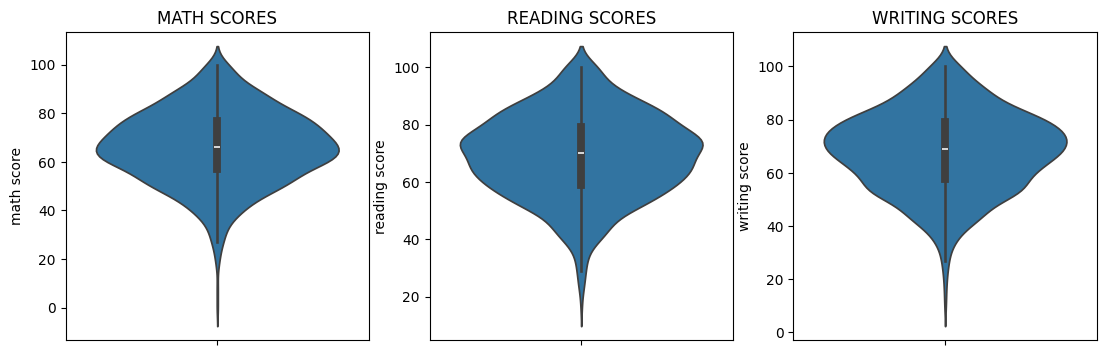

In [100]:
# Scores in different subject

plt.figure(figsize=(18,4))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score',data=df)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score',data=df)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score',data=df)
# plt.subplot(1,4,4)
# plt.title('Gender wise')
# sns.violinplot(data=df, x='gender', y='total')
plt.show()

Conclusion:
1. In maths most of students score 55-65 marks
2. In reading and writing most of students around 60-80 marks

In [121]:
gender_counts = df['gender'].value_counts()
print(gender_counts)
print(gender_counts.index)
print(gender_counts.values)

gender
female    518
male      482
Name: count, dtype: int64
Index(['female', 'male'], dtype='object', name='gender')
[518 482]


### Multivariate analysis using pieplot

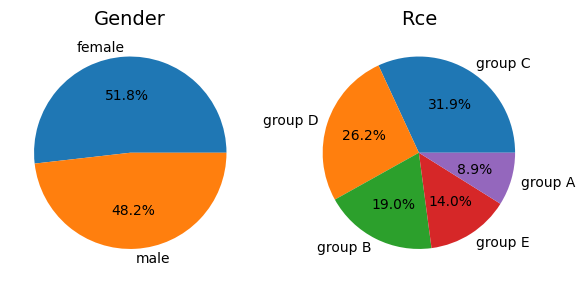

In [ ]:
# Pie plot
plt.figure(figsize=(18,4))

plt.subplot(1,5,1)
gender_counts = df['gender'].value_counts()
plt.title('Gender',fontsize='14')
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)


plt.subplot(1,5,2)
race_counts = df['race'].value_counts()
plt.title('Race',fontsize='14')
plt.pie(
    race_counts,
    labels=race_counts.index,
    autopct='%1.1f%%'
)


plt.show()

In [ ]:
categorical_columns

Index(['gender', 'race', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')

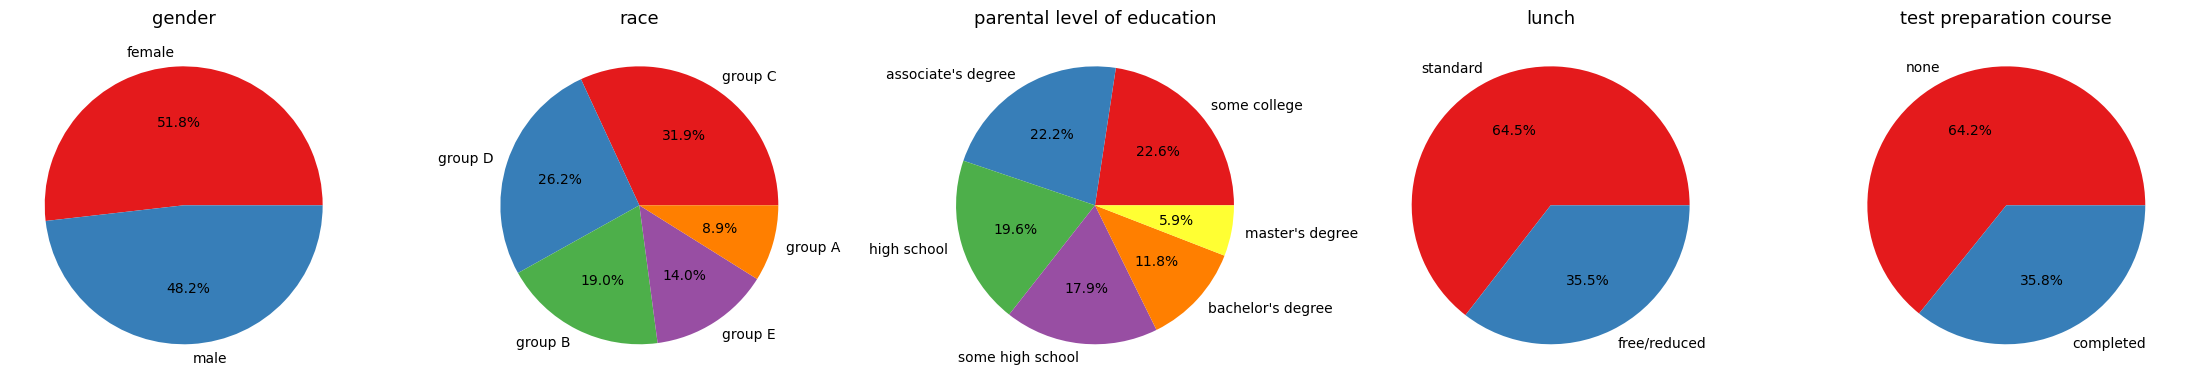

In [154]:
plt.figure(figsize=(22,5))

size = len(categorical_columns)

for i in range(size):
    plt.subplot(1, size, i+1)

    col = categorical_columns[i]
    counts = df[col].value_counts()

    plt.title(col, fontsize=13)
    
    colors = plt.cm.Set1(range(len(counts)))

    plt.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        textprops={'fontsize':10},
        colors=colors
    )

plt.tight_layout()
plt.show()

### Feature Wise Visualization


In [348]:
df.head()

,gender,race,parental level of education,lunch,test preparation course,math score,reading score,writing score,total,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


#### Gender Column
1. Univariate analysis (Gender wise distribution of students)
2. BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

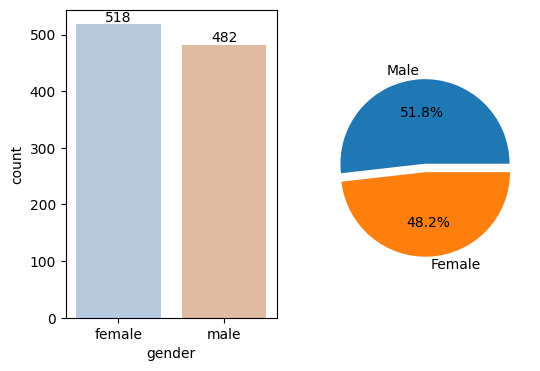

In [187]:
f,ax = plt.subplots(1,2,figsize=(6,4))

sns.countplot(x=df['gender'],data=df,palette ='pastel',hue='gender',ax=ax[0],saturation=0.5)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=10)
    
ax[1].pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%')

plt.show()

In [197]:
gender_group = df.groupby('gender')[numerical_columns].mean()
gender_group

,math score,reading score,writing score,total,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


In [ ]:
male_scores = gender_group.loc[
    'male',
    ['math score', 'reading score', 'writing score']
].values

male_scores

array([68.72821577, 65.47302905, 63.31120332])

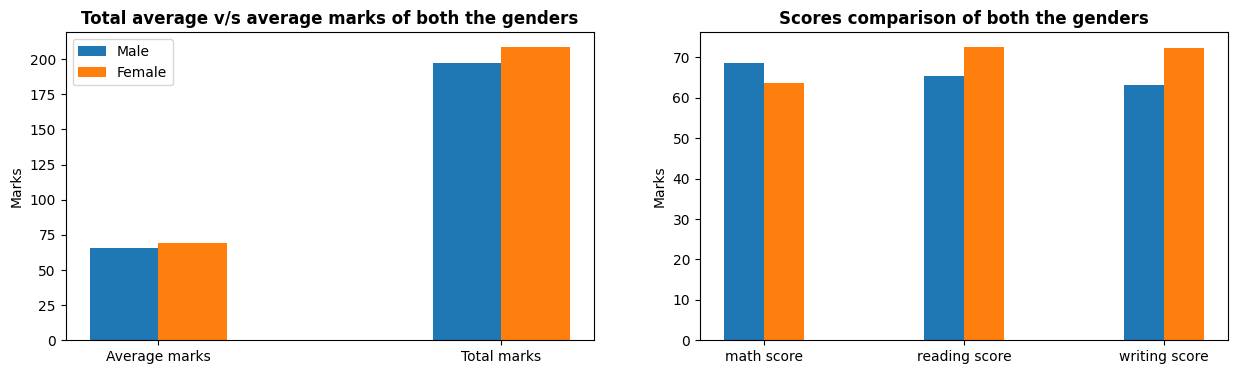

In [229]:
plt.figure(figsize=(15, 4))

plt.subplot(121)
X = ['Average marks','Total marks']

female_scores = [gender_group.average.female, gender_group.total.female]
male_scores = [gender_group.average.male, gender_group.total.male]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.1, male_scores, 0.2, label = 'Male')
plt.bar(X_axis + 0.1, female_scores, 0.2, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s average marks of both the genders", fontweight='bold')
plt.legend()




plt.subplot(122)
X = ['math score', 'reading score', 'writing score']

male_scores = gender_group.loc['male',X].values
female_scores = gender_group.loc['female',X].values

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.1, male_scores, 0.2, label = 'Male')
plt.bar(X_axis + 0.1, female_scores, 0.2, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Scores comparison of both the genders", fontweight='bold')
plt.show()

Female have better score
Whereas in maths male outperforms

#### Race/Ethnicity Column
1. Univariate analysis
2. BIVARIATE ANALYSIS ( Does race/ethnicity has any impact on student's performance ? ) 

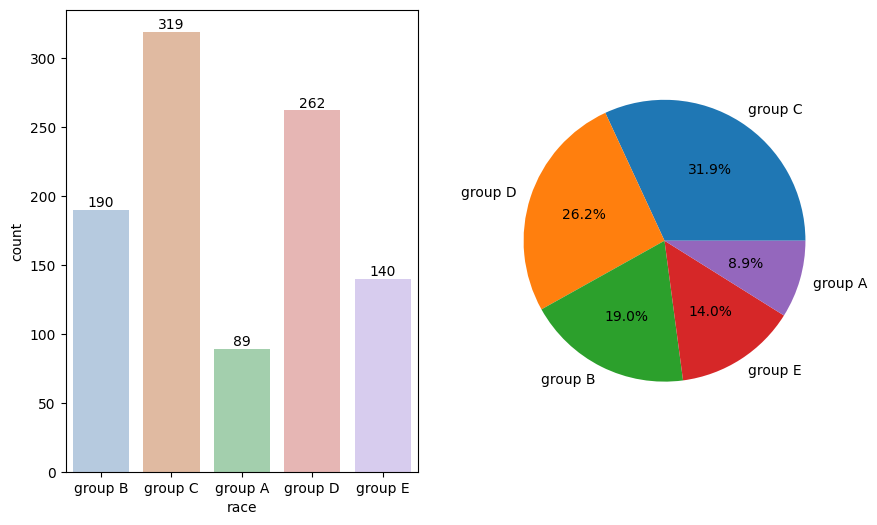

In [259]:
f,ax = plt.subplots(1,2,figsize=(10,6))

sns.countplot(x=df['race'],data=df,palette ='pastel',hue='race',ax=ax[0],saturation=0.5)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=10)


race_values = df.race.value_counts()
ax[1].pie(x=race_values,labels=race_values.index,autopct='%1.1f%%')

plt.show()

In [352]:
race_group = df.groupby('race')[numerical_columns].mean()
race_group = race_group.reset_index()
race_group

,race,math score,reading score,writing score,total,average
0,group A,61.629213,64.674157,62.674157,188.977528,62.992509
1,group B,63.452632,67.352632,65.600000,196.405263,65.468421
2,group C,64.463950,69.103448,67.827586,201.394984,67.131661
3,group D,67.362595,70.030534,70.145038,207.538168,69.179389
4,group E,73.821429,73.028571,71.407143,218.257143,72.752381


Most students are from group C and D
Group A has least number of students

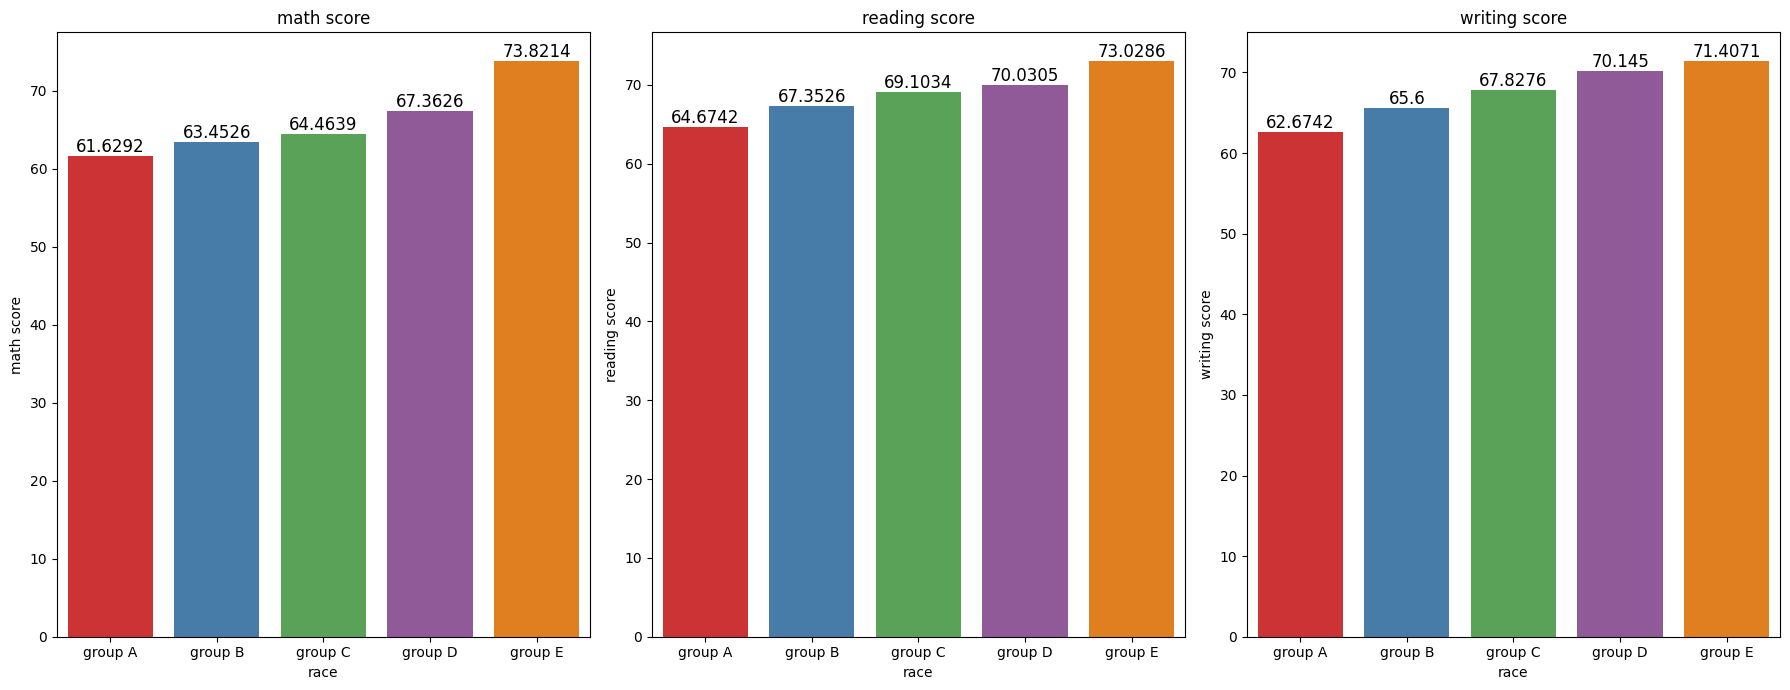

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,7))

scores = ['math score', 'reading score', 'writing score']
race_group = df.groupby('race')[scores].mean()
race_group = race_group.reset_index()

for i, score in enumerate(scores):

    sns.barplot(
        data=race_group,
        x='race',
        y=score,  
        hue='race',
        palette='Set1',
        legend=False,
        ax=ax[i]
    )
    # sns.barplot(
    #     x=race_group.index,
    #     y=race_group[score],
    #     hue=race_group.index,
    #     palette='Set1',
    #     legend=False,
    #     ax=ax[i]
    # )

    ax[i].set_title(score)

    # Add labels
    for container in ax[i].containers:
        ax[i].bar_label(container, color='black', size=12)

plt.tight_layout()
plt.show()

Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 

In [334]:
scores = ['math score', 'reading score', 'writing score']

race_group = df.groupby('race')[scores].mean().reset_index()

# Wide -> long format
race_melt = race_group.melt(
    id_vars='race',
    value_vars=scores,
    var_name='Subject',
    value_name='Marks'
)

race_melt

,race,Subject,Marks
0,group A,math score,61.629213
1,group B,math score,63.452632
2,group C,math score,64.463950
3,group D,math score,67.362595
4,group E,math score,73.821429
5,group A,reading score,64.674157
6,group B,reading score,67.352632
7,group C,reading score,69.103448
8,group D,reading score,70.030534
9,group E,reading score,73.028571


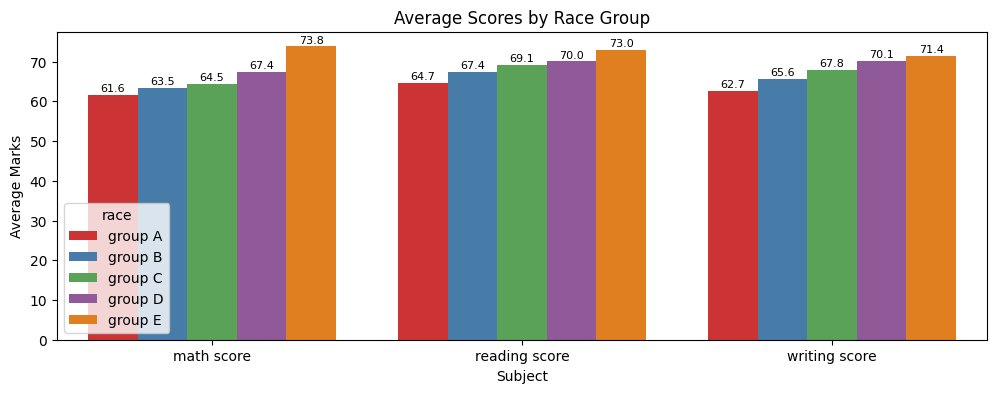

In [347]:
scores = ['math score', 'reading score', 'writing score']

race_group = df.groupby('race')[scores].mean().reset_index()

# Wide -> long format
race_melt = race_group.melt(
    id_vars='race',
    value_vars=scores,
    var_name='Subject',
    value_name='Marks'
)

plt.figure(figsize=(12,4))

ax = sns.barplot(
    data=race_melt,
    x='Subject',
    y='Marks',
    hue='race',
    palette='Set1',
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=1, size='8')

plt.title('Average Scores by Race Group')
plt.ylabel('Average Marks')

plt.show()

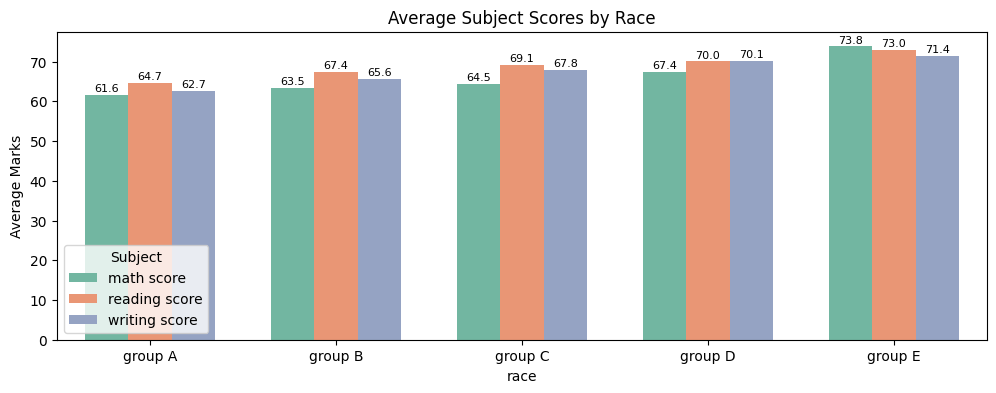

In [ ]:
scores = ['math score', 'reading score', 'writing score']

race_group = df.groupby('race')[scores].mean().reset_index()

# Convert wide -> long
race_melt = race_group.melt(
    id_vars='race',
    value_vars=scores,
    var_name='Subject',
    value_name='Marks'
)

plt.figure(figsize=(12,4))

ax = sns.barplot(
    data=race_melt,
    x='race',          # first grouping = race
    y='Marks',
    hue='Subject',     # inside each race -> 3 bars
    palette='Set2',
    width=0.7
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=1, size='8')

plt.title('Average Subject Scores by Race')
plt.ylabel('Average Marks')

plt.show()



#### Parental level of education Column
1. Univariate analysis (Parental level of education wise distribution of students)
2. BIVARIATE ANALYSIS ( Does parental level of education has any impact on student's performance ? ) 

In [351]:
df['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

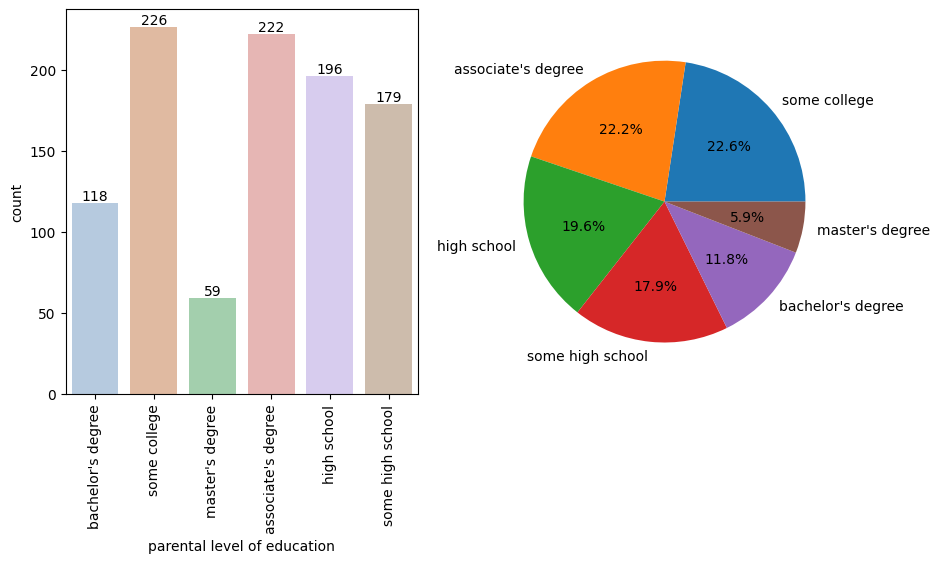

In [362]:
f,ax = plt.subplots(1,2,figsize=(10,5))

sns.countplot(x=df['parental level of education'],data=df,palette ='pastel',hue='parental level of education',ax=ax[0],saturation=0.5)
ax[0].tick_params(axis='x', rotation=90)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=10)


count_values = df['parental level of education'].value_counts()
ax[1].pie(x=count_values,labels=count_values.index,autopct='%1.1f%%')

plt.show()

- Largest number of parents are from some college.

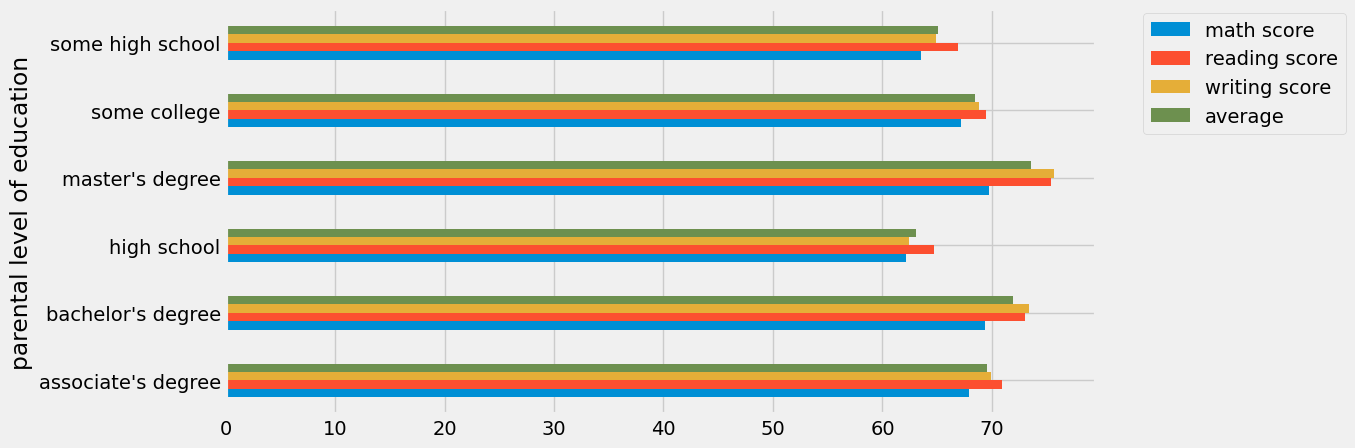

In [399]:
score_features = ['math score', 'reading score','writing score','average']
df.groupby('parental level of education')[score_features].agg('mean',).plot(kind='barh',figsize=(10,5))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.2)
plt.show()

The score of student whose parents possess master and bachelor level education are higher than others.

#### Lunch Column
1. Univariate analysis (Which type of lunch is most common amoung students ?)
2. BIVARIATE ANALYSIS (Effect of lunch type on test results? ) 

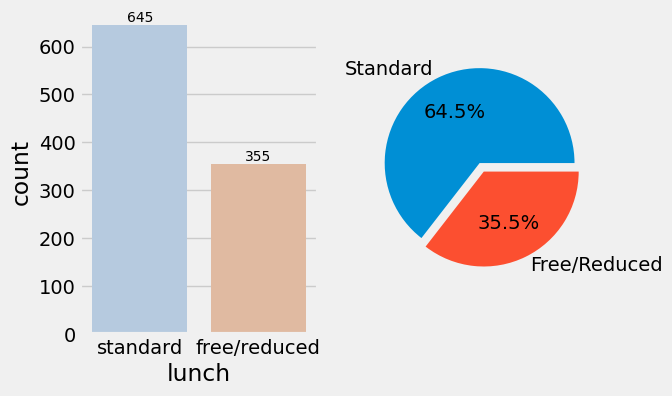

In [410]:
# plt.figure(figsize=(8, 4))
# sns.countplot(df['lunch'])
# plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20,)
# plt.xlabel('types of lunch')
# plt.ylabel('count')
# plt.show()

f,ax = plt.subplots(1,2,figsize=(6,4))

sns.countplot(x=df['lunch'],data=df,palette ='pastel',hue='lunch',ax=ax[0],saturation=0.5)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=10)
    
ax[1].pie(x=df['lunch'].value_counts(),labels=['Standard','Free/Reduced'],explode=[0.1,0],autopct='%1.1f%%')

plt.show()

Students being served Standard lunch was more than free lunch

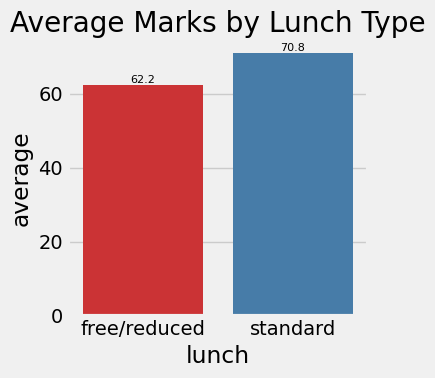

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(4,4))

scores = ['average']

race_group = df.groupby('lunch')[scores].mean().reset_index()

sns.barplot(
    data=race_group,
    x='lunch',
    y='average',
    hue='lunch',
    palette='Set1',
    legend=False,
    ax=ax
)

ax.set_title('Average Marks by Lunch Type')

# Add labels
for container in ax.containers:
    ax.bar_label(container, color='black', size=8, fmt='%1.1f')

plt.tight_layout()
plt.show()

Students being served Standard lunch perform better than free lunch students had better average score 

#### test preparation course Column
1. Univariate analysis
2. BIVARIATE ANALYSIS 

In [457]:
df['test preparation course'].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

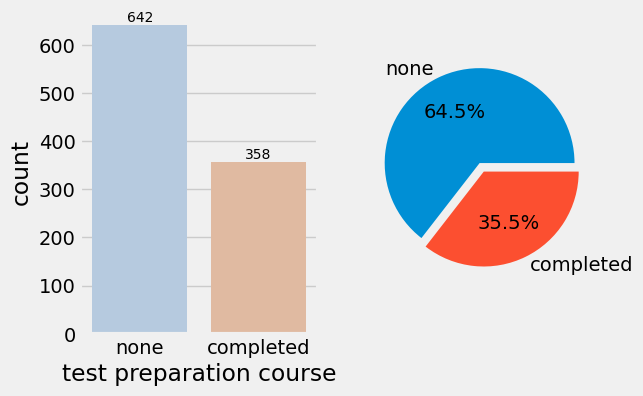

In [459]:
f,ax = plt.subplots(1,2,figsize=(6,4))

sns.countplot(x=df['test preparation course'],data=df,palette ='pastel',hue='test preparation course',ax=ax[0],saturation=0.5)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=10)
    
ax[1].pie(x=df['lunch'].value_counts(),labels=['none','completed'],explode=[0.1,0],autopct='%1.1f%%')

plt.show()

Most of students did not complete the test preparation course

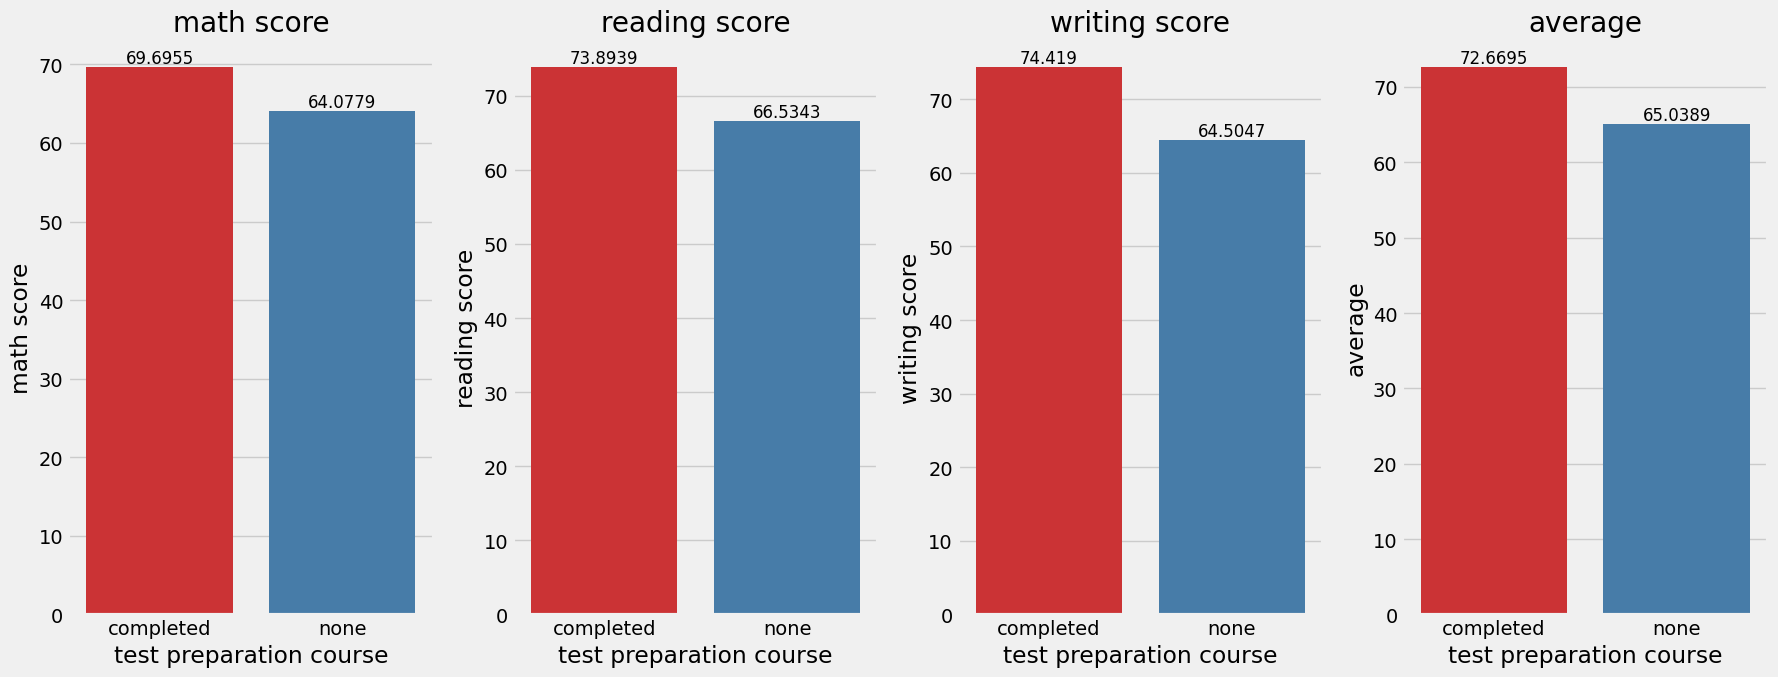

In [463]:
fig, ax = plt.subplots(1, 4, figsize=(18,7))

scores = ['math score', 'reading score', 'writing score','average']
race_group = df.groupby('test preparation course')[scores].mean()
race_group = race_group.reset_index()

for i, score in enumerate(scores):

    sns.barplot(
        data=race_group,
        x='test preparation course',
        y=score,  
        hue='test preparation course',
        palette='Set1',
        legend=False,
        ax=ax[i]
    )

    ax[i].set_title(score)

    # Add labels
    for container in ax[i].containers:
        ax[i].bar_label(container, color='black', size=12)

plt.tight_layout()
plt.show()

Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

### Checking Outliers


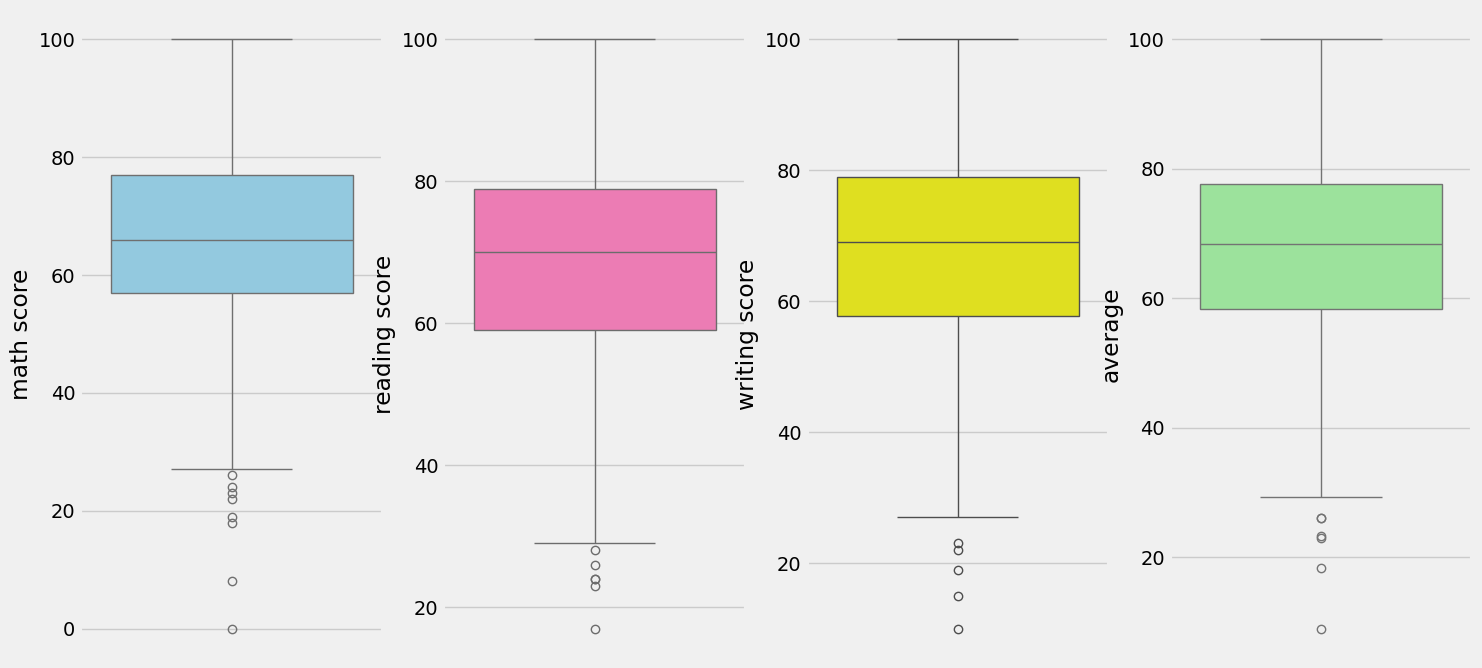

In [472]:
plt.subplots(1,4,figsize=(16,8))

plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')

plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')

plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')

plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')

plt.show()

The dataset shows several low-score outliers, particularly in math scores, whereas high scores remain within the normal range.

### Multivariate Analysis using Pairplot

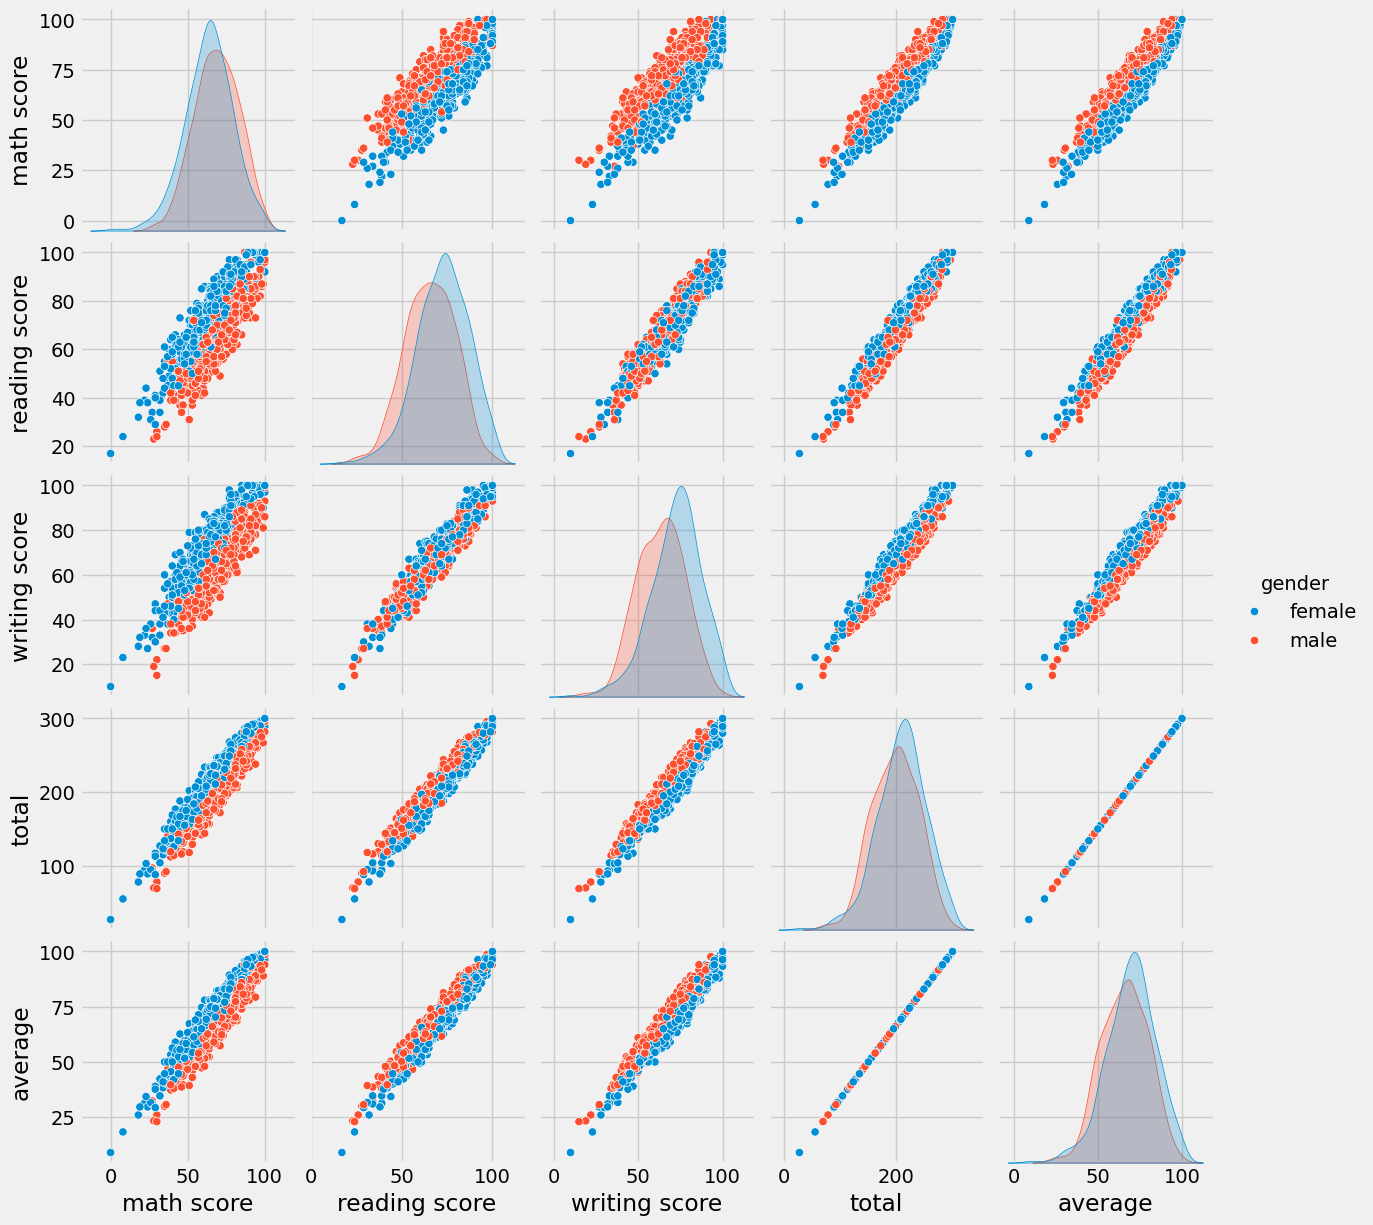

In [473]:
sns.pairplot(df,hue = 'gender')
plt.show()

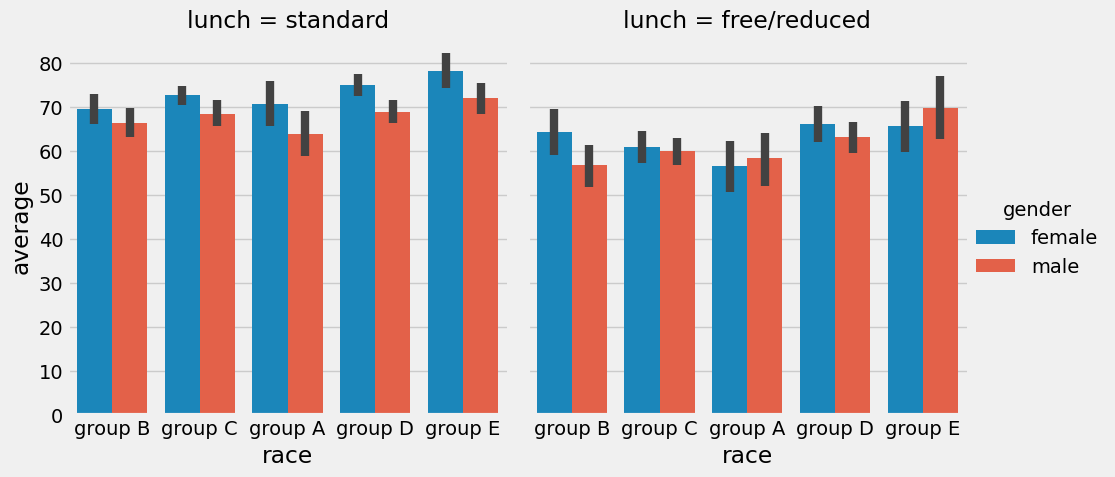

In [480]:
sns.catplot(
    data=df,
    x='race',
    y='average',
    hue='gender',
    col='lunch',
    kind='bar'
)

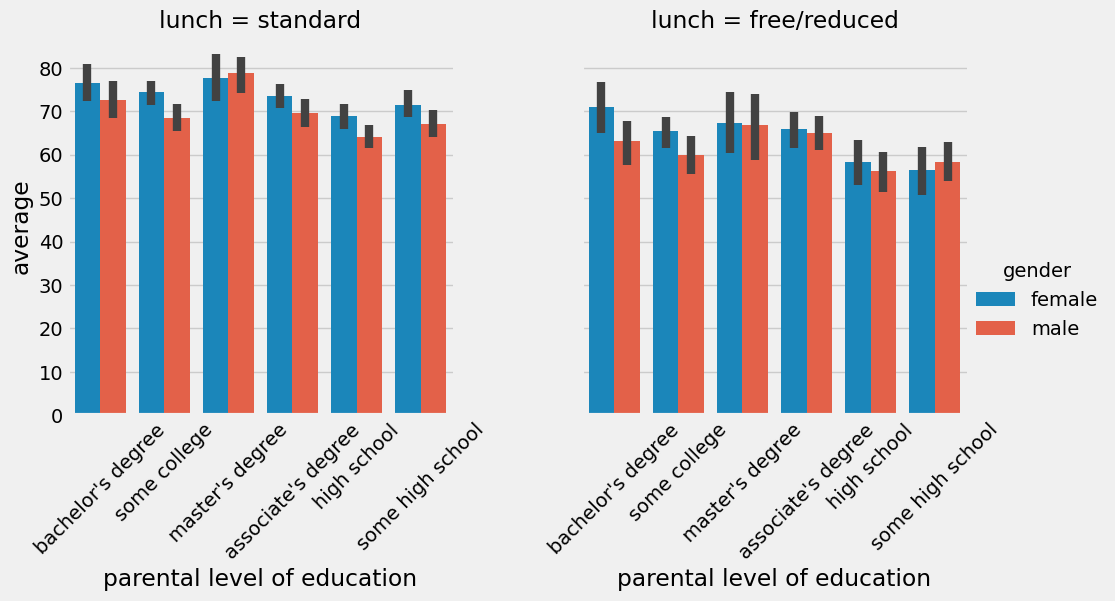

In [492]:
plt.Figure(figsize=(12,6))

g= sns.catplot(
    data=df,
    x='parental level of education',
    y='average',
    hue='gender',
    col='lunch',
    kind='bar'
)

g.set_xticklabels(rotation=45)
plt.show()

<Axes: >

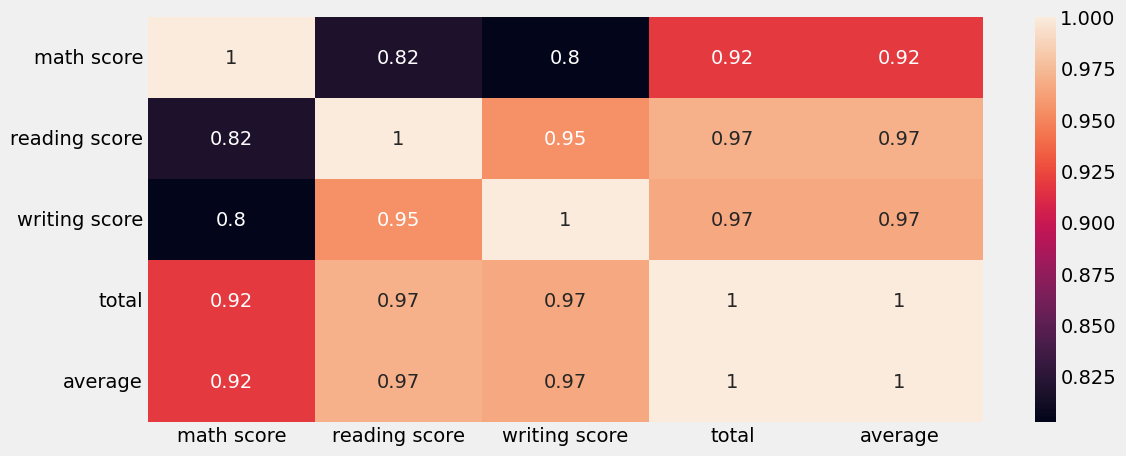

In [481]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='race', ylabel='average'>

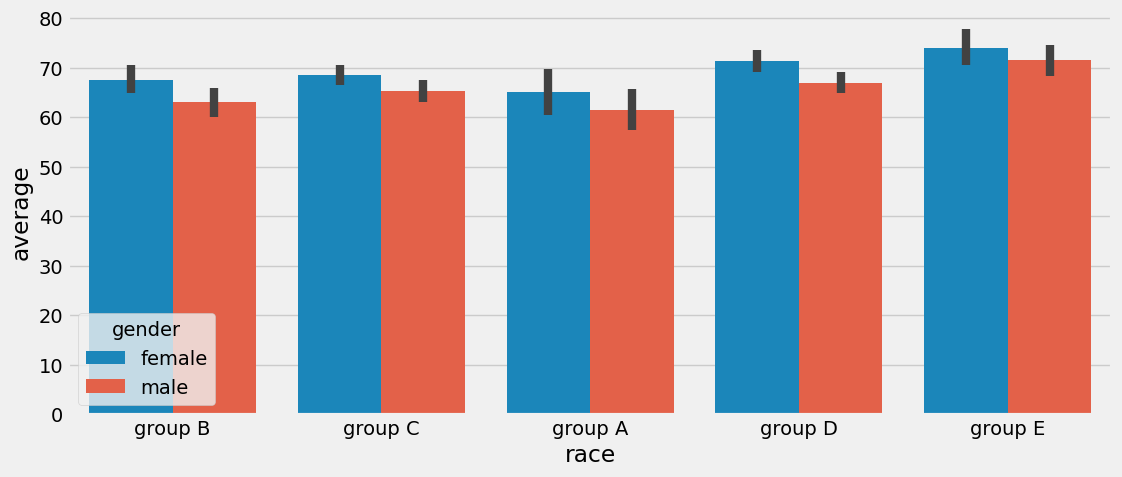

In [482]:
sns.barplot(
    data=df,
    x='race',
    y='average',
    hue='gender'
)